准备环境

In [16]:
!pip install scikit-learn -q


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


导入所需库

In [17]:
# 基础库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 机器学习库
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 化学信息学
from rdkit import Chem
from rdkit.Chem import Descriptors

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print('所有库导入成功！')

所有库导入成功！


准备数据
两样东西：1.特征(X):用来做预测的输入数据。2.标签(y):要预测的结果，比如1=可口服吸收，0=不可口服吸收
X 是一个二维数组（矩阵），每行一个药物，每列一个特征
y 是一个一维数组，每个元素对应 X 中同一行的标签
X.shape[1] 返回列数（特征数），shape 是 NumPy 里查看数组形状的属性

In [18]:
# 特征：每种药物的 [分子量, LogP, 氢键受体数, 氢键供体数]
X = np.array([
    [180, 1.19, 4, 1],   # aspirin
    [194, 0.07, 6, 0],   # caffeine
    [151, 0.46, 2, 2],   # paracetamol
    [206, 3.97, 2, 1],   # ibuprofen
    [580, 4.50, 8, 3],   # 大分子药物
    [520, 6.20, 11, 4],  # 违反Lipinski的药物
    [340, 2.10, 5, 2],   # 中等分子
    [450, 3.50, 6, 3],   # 接近边界的药物
    [165, 0.80, 3, 1],   # 小分子药物
    [610, 5.80, 10, 5],  # 明显不合格
])

# 标签：1=符合口服药物标准，0=不符合
y = np.array([1, 1, 1, 1, 0, 0, 1, 0, 1, 0])

print(f'数据量: {len(X)} 条')
print(f'特征数: {X.shape[1]} 个')
print(f'正样本(合格): {y.sum()} 条')
print(f'负样本(不合格): {len(y) - y.sum()} 条')

数据量: 10 条
特征数: 4 个
正样本(合格): 6 条
负样本(不合格): 4 条


划分训练集和测试集，就好比不能用同一组数据及训练又考试

In [19]:
# 把数据分成 70% 训练集 + 30% 测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#text_size=0.3 表示测试集占总数据的 30%，random_state=42 是随机种子，保证每次运行结果一致。

print(f'训练集: {len(X_train)} 条')
print(f'测试集: {len(X_test)} 条')
print(f'训练集标签: {y_train}')
print(f'测试集标签: {y_test}')

# X-train 训练特征  X-test 测试特征  y-train 训练标签  y-test 测试标签

训练集: 7 条
测试集: 3 条
训练集标签: [1 0 1 0 0 1 1]
测试集标签: [1 1 0]


训练模型，用随机森林模型(Random Forest)。 步骤：创建模型，训练模型，预测

In [20]:
# 第一步：创建模型
model = RandomForestClassifier(random_state=42, n_estimators=1000)

# 第二步：训练（让模型从训练数据中学规律）
model.fit(X_train, y_train)

print('模型训练完成！')

模型训练完成！


预测，评估

In [21]:
y_pred = model.predict(X_test)      # 第三步，用测试集测试

print('真实标签:', y_test)
print('预测标签:', y_pred)
print('准确率:', accuracy_score(y_test, y_pred))    #accuracy_score 函数计算准确率,预测对了多少个除以总数

真实标签: [1 1 0]
预测标签: [1 1 0]
准确率: 1.0


为什么不能用训练数据评估模型，因为用训练数据得出的结果不一定可靠，很可能是“背答案”，要用测试集即模型没见过的数据来检验其泛化能力


In [22]:
# 用训练数据评估（这是错误的做法，只用来演示）
train_pred = model.predict(X_train)
print('训练集准确率:', accuracy_score(y_train, train_pred))

# 用测试数据评估（这才是正确的做法）
test_pred = model.predict(X_test)
print('测试集准确率:', accuracy_score(y_test, test_pred))

训练集准确率: 1.0
测试集准确率: 1.0


过拟合：训练集好，数据集差          欠拟合：训练集和测试集都差
过拟合是机器学习的常见问题，常见的解决方法包括：1.增加数据量    2.简化模型(减少参数)    3.使用正则化    4。交叉验证

交叉验证：把数据分成多份，轮流用其中一份做测试，其余做训练，最后取平均，避免一次划分测试可能不靠谱，因为可能划分恰好有利或不有利呢

In [23]:
from sklearn.model_selection import cross_val_score #导入模块

# 5 折交叉验证
scores = cross_val_score(model, X, y, cv=5) #cv =5,把数据分成五份，轮流做五次测试

print('5次交叉验证准确率:', scores) # scores 是一个数组，包含每次交叉验证的准确率,这里就是5次测试的准确率数组
print('平均准确率:', scores.mean()) # wscores.mean() 计算平均准确率比单次可靠
print('标准差:', scores.std())  # scores.std() 计算标准差，标准差越小，说明模型的稳定性越好

c:\Users\JJFY\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


5次交叉验证准确率: [1. 1. 1. 1. 1.]
平均准确率: 1.0
标准差: 0.0


混淆矩阵:
[[1 0]
 [0 2]]


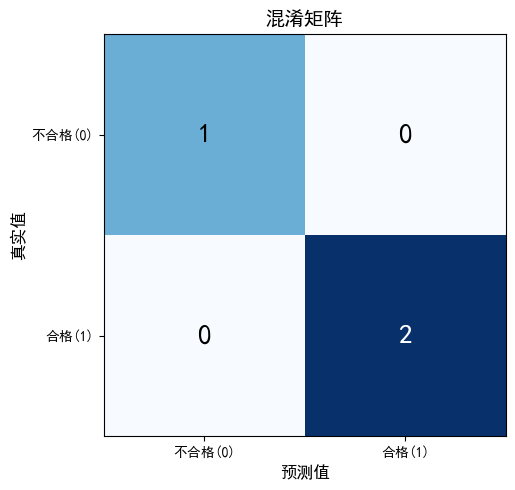

In [ ]:
# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)   #confusion_matrix(真实值，测试值)生成一个2*2矩阵
print('混淆矩阵:')
print(cm)

# 可视化
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')    # ax.imshow(矩阵，cmap='Blues')把一个数字矩阵画成颜色方块图，数字越大颜色越深，越小越浅
ax.set_xticks([0, 1])   #告诉matplotlib在X轴0和1位置放刻度
ax.set_yticks([0, 1])
ax.set_xticklabels(['不合格(0)', '合格(1)'])    # 把刻度的数字替换成中文文字
ax.set_yticklabels(['不合格(0)', '合格(1)'])
ax.set_xlabel('预测值', fontsize=12)
ax.set_ylabel('真实值', fontsize=12)
ax.set_title('混淆矩阵', fontsize=14)

# 在每个格子里写数字
for i in range(2):  # 外层:遍历行(i=0,i=1),外层管行，从左到右
    for j in range(2):  #内层:遍历行(j=0,j=1)，内层管列，从上到下
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=20, # str(cm[i, j],要显示的数。ha='center',水平居中。va='center，垂直居中。
                color='white' if cm[i, j] > cm.max()/2 else 'black')    #cm.max,最大值。
        
#上述的是一个嵌套循环，会产生四次结果，即外层i=0,内层依次是j=0,j=1,然后是i=1,内层依旧是j=0,j=1,那么为什么，外层循环一次，
#内层循环两次，因为这个嵌套循环，是按照顺序一层一层运行，外层循环一次，内层的代码要完全运行完成才能进行下次循环，这里是range(2)
#range(2)输出(0,1),所以每一层会输出两个值，所有最终会有四个结果

plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(y_test, y_pred, target_names=['不合格', '合格']))   #可以一键生成所有指标的工具

#精确率(precision):模型说合格的里面，真正合格的比例，TP/(TP+FP)
#召回率(Recall):真正合格的药物里，模型找出来了多少，TP/(TP+FN)
#F1_score:精确率和召回率的调和平均，2*P*R/(P+R)

              precision    recall  f1-score   support

         不合格       1.00      1.00      1.00         1
          合格       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

